# LG-OMPC — Language-Guided Objective Model Predictive Control

### A guided walkthrough of the framework, end to end

This notebook teaches the **LG-OMPC** framework by building a tiny world, asking a
language model to *write the objective function for us*, and watching a discrete
Model Predictive Controller (MPC) plan and act to reach a goal — with **no reward
shaping hand-coded anywhere**.

> **The one-sentence idea**
>
> The **LLM** decides *what matters*. The **world model** predicts *what happens*.
> **MPC** decides *what to do next*.

By the end you will have seen every moving part: how you *model* a world, how it is
*serialized* for the LLM, how the LLM *synthesizes* an objective, how that objective
is *sandboxed*, and how the planner *optimizes* over a receding horizon.

## Why this is interesting

Classical control needs you to hand-write a cost function for every new task. That is
the hard, brittle part: a reward that works in one setting fails in another. LG-OMPC
asks a different question:

> *Can a language model read a structured description of a situation and a goal, and
> then write the objective function itself?*

If yes, the same planner can solve many tasks — the **task understanding** moves into
language, while the **action optimization** stays a clean, well-understood search.

The pipeline below is what we will build, one block at a time.

In [53]:
# --- Notebook setup: make the package importable and load the .env key -------
import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Walk upward until we find the repo (identified by pyproject.toml)."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))


def load_dotenv(path: Path) -> bool:
    """Minimal .env loader: existing environment variables always win."""
    if not path.exists():
        return False
    for line in path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, _, value = line.partition("=")
            os.environ.setdefault(key.strip(), value.strip())
    return True


has_env = load_dotenv(REPO_ROOT / ".env")
HAS_API_KEY = bool(os.environ.get("LLM_API_KEY"))
print(f"Repo root : {REPO_ROOT}")
print(f".env found : {has_env}")
print(f"API key set : {HAS_API_KEY}  (model: {os.environ.get('LLM_MODEL', 'gpt-5.2')})")

Repo root : /home/kareem/repos/lg-ompc
.env found : True
API key set : True  (model: gpt-5.2)


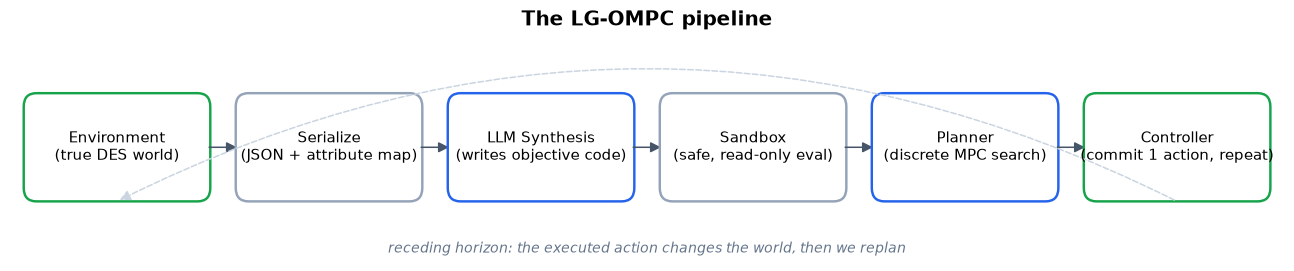

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True})
ACCENT = "#2563eb"
ACCENT2 = "#16a34a"
MUTED = "#94a3b8"


def draw_pipeline():
    """Draw the LG-OMPC data-flow as labelled boxes."""
    stages = [
        ("Environment\n(true DES world)", ACCENT2),
        ("Serialize\n(JSON + attribute map)", MUTED),
        ("LLM Synthesis\n(writes objective code)", ACCENT),
        ("Sandbox\n(safe, read-only eval)", MUTED),
        ("Planner\n(discrete MPC search)", ACCENT),
        ("Controller\n(commit 1 action, repeat)", ACCENT2),
    ]
    fig, ax = plt.subplots(figsize=(12, 2.6))
    ax.set_xlim(0, len(stages)); ax.set_ylim(0, 1); ax.axis("off")
    for i, (label, color) in enumerate(stages):
        box = FancyBboxPatch((i + 0.08, 0.28), 0.84, 0.44,
                             boxstyle="round,pad=0.02,rounding_size=0.06",
                             linewidth=1.6, edgecolor=color, facecolor="white")
        ax.add_patch(box)
        ax.text(i + 0.5, 0.5, label, ha="center", va="center", fontsize=9.5)
        if i < len(stages) - 1:
            ax.add_patch(FancyArrowPatch((i + 0.92, 0.5), (i + 1.08, 0.5),
                                         arrowstyle="-|>", mutation_scale=14,
                                         color="#475569"))
    ax.add_patch(FancyArrowPatch((len(stages) - 0.5, 0.26), (0.5, 0.26),
                                 connectionstyle="arc3,rad=0.25", arrowstyle="-|>",
                                 mutation_scale=14, color="#cbd5e1", linestyle="--"))
    ax.text(len(stages) / 2, 0.05, "receding horizon: the executed action changes the world, then we replan",
            ha="center", va="center", fontsize=9, color="#64748b", style="italic")
    ax.set_title("The LG-OMPC pipeline", fontsize=13, weight="bold")
    plt.tight_layout(); plt.show()


draw_pipeline()

## Step 1 — Model the world

We will build a deliberately tiny scenario so every step is inspectable:

> A **human** is thirsty and standing at position `0`. A **water bottle** sits at
> position `3`. The human can `walk`, `pick_up` the bottle, and `drink_from` it.
> The goal: *become hydrated while spending as little effort as possible.*

In LG-OMPC a world is made of three kinds of object you subclass from the framework:

| Concept | Framework type | Role |
|---|---|---|
| **Action** | `ActionSpec` | A verb with a *precondition* (can it run?) and an *effect* (what changes). |
| **Entity** | `Entity` | A thing with mutable `state` that offers *outgoing* and *incoming* actions. |
| **Environment** | `Environment` | The true system: enumerates actions, applies them, clones itself for search. |

A key design rule: **affordance lives in code, desirability lives in the LLM.** Whether
the human *can* drink (holding a full bottle) is a precondition here. Whether it
*should* drink is decided later by the synthesized objective.

In [55]:
from lg_ompc import (
    ActionDirection,
    ActionSpec,
    Entity,
    Environment,
    Relation,
    RelationKind,
)

HUMAN, BOTTLE = "human", "water_bottle"


def _sign(x: int) -> int:
    return (x > 0) - (x < 0)


# --- WALK: move one step toward the target (precondition: not already there) ---
def _can_walk(env, a):
    return env.entity(a.actor).state["position"] != env.entity(a.target).state["position"]


def _walk(env, a):
    actor, target = env.entity(a.actor), env.entity(a.target)
    step = _sign(target.state["position"] - actor.state["position"])
    actor.state["position"] += step


# --- PICK_UP: grab the bottle (precondition: adjacent and hands empty) ---------
def _can_pick_up(env, a):
    actor, bottle = env.entity(a.actor), env.entity(a.target)
    return actor.state["position"] == bottle.state["position"] and actor.state.get("holding") is None


def _pick_up(env, a):
    env.entity(a.actor).state["holding"] = a.target


# --- DRINK_FROM: become hydrated (precondition: holding a bottle with water) ----
def _can_drink(env, a):
    actor, bottle = env.entity(a.actor), env.entity(a.target)
    return actor.state.get("holding") == a.target and bool(bottle.state.get("contains_water"))


def _drink(env, a):
    env.entity(a.actor).state["hydration"] = "high"
    env.entity(a.target).state["contains_water"] = False


WALK = ActionSpec("walk", ActionDirection.OUTGOING, _walk, _can_walk)
PICK_UP = ActionSpec("pick_up", ActionDirection.INCOMING, _pick_up, _can_pick_up)
DRINK_FROM = ActionSpec("drink_from", ActionDirection.INCOMING, _drink, _can_drink)
print("Defined 3 action specs:", WALK.name, PICK_UP.name, DRINK_FROM.name)

Defined 3 action specs: walk pick_up drink_from


Notice the split: a `human` is an **active** entity (it has an outgoing `walk`), while
a `water_bottle` is **passive** — it does nothing on its own but *receives* `pick_up`
and `drink_from`. Passive does not mean irrelevant: the bottle is essential to the
goal. This mirrors the `A_out` / `A_in` split from the formal definition.

In [56]:
class Human(Entity):
    kind = "active_agent"

    def outgoing_actions(self):
        return [WALK]

    def incoming_actions(self):
        return []


class WaterBottle(Entity):
    kind = "passive_object"

    def outgoing_actions(self):
        return []

    def incoming_actions(self):
        return [PICK_UP, DRINK_FROM]


class HydrationWorld(Environment):
    """The true system. `compute_relations` exposes between-entity facts (distance);
    `is_terminal` defines what 'goal reached' means."""

    def compute_relations(self):
        d = abs(self.entity(HUMAN).state["position"] - self.entity(BOTTLE).state["position"])
        return [Relation(RelationKind.SPATIAL, "distance", HUMAN, BOTTLE, float(d))]

    def is_terminal(self):
        return self.entity(HUMAN).state.get("hydration") == "high"


def build_world():
    human = Human(HUMAN, {"position": 0, "hydration": "low", "holding": None},
                  purposes=["remain_safe", "be_hydrated", "complete_task"])
    bottle = WaterBottle(BOTTLE, {"position": 3, "contains_water": True},
                         purposes=["hydrate_agent", "store_water"])
    return HydrationWorld([human, bottle],
                          goal="The human should drink the water bottle while spending as little effort as possible.")


world = build_world()
print("human is_active :", world.entity(HUMAN).is_active)
print("bottle is_passive:", world.entity(BOTTLE).is_passive)
print("initial applicable actions:", [str(a) for a in world.available_actions()])

human is_active : True
bottle is_passive: True
initial applicable actions: ['human.walk(water_bottle)']


### Visualizing the world

Positions are one-dimensional integers, so we can draw the whole world on a number
line. This is the state the planner will reason about.

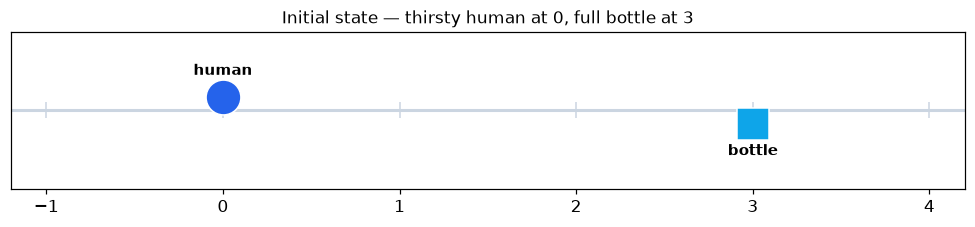

In [57]:
def draw_world(env, ax=None, title=None):
    """Render the 1-D world: human and bottle on a number line."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(9, 2.2))
    h = env.entity(HUMAN); b = env.entity(BOTTLE)
    ax.axhline(0, color="#cbd5e1", lw=2, zorder=0)
    for x in range(-1, 5):
        ax.plot(x, 0, marker="|", color="#cbd5e1", ms=10)
    hydrated = h.state.get("hydration") == "high"
    ax.scatter(h.state["position"], 0.12, s=520, marker="o",
               color=ACCENT2 if hydrated else ACCENT, zorder=3, edgecolor="white")
    ax.text(h.state["position"], 0.32, "human", ha="center", fontsize=10, weight="bold")
    full = b.state.get("contains_water")
    ax.scatter(b.state["position"], -0.12, s=420, marker="s",
               color="#0ea5e9" if full else "#e2e8f0", zorder=3, edgecolor="white")
    ax.text(b.state["position"], -0.4, "bottle" + ("" if full else " (empty)"),
            ha="center", fontsize=10, weight="bold")
    held = h.state.get("holding") is not None
    badge = f"hydration={h.state.get('hydration')}   holding={'bottle' if held else 'nothing'}"
    ax.set_xlim(-1.2, 4.2); ax.set_ylim(-0.7, 0.7); ax.set_yticks([])
    ax.set_xticks(range(-1, 5)); ax.grid(False)
    ax.set_title(title or badge, fontsize=11)
    if own:
        plt.tight_layout(); plt.show()


draw_world(build_world(), title="Initial state \u2014 thirsty human at 0, full bottle at 3")

## Step 2 — Serialize the world for the LLM

The LLM never sees Python objects; it sees a **structured description**. `describe()`
is the single source of truth for *what the model knows*. Crucially it emits an
`attribute_map`: the exact dotted attribute paths the objective is allowed to read
(e.g. `human.hydration`). Advertising the real names up front removes a whole class of
*attribute hallucination* bugs.

In [58]:
from lg_ompc import describe

description = describe(build_world())
print("ATTRIBUTE MAP (what the objective may read):")
for path, type_name in description.attribute_map.items():
    print(f"  {path:<28} : {type_name}")
print("\nFull JSON sent to the LLM:\n")
print(description.to_prompt_json())

ATTRIBUTE MAP (what the objective may read):
  human.position               : int
  human.hydration              : str
  human.holding                : NoneType
  water_bottle.position        : int
  water_bottle.contains_water  : bool

Full JSON sent to the LLM:

{
  "goal": "The human should drink the water bottle while spending as little effort as possible.",
  "entities": [
    {
      "name": "human",
      "kind": "active_agent",
      "role": "active",
      "state": {
        "position": 0,
        "hydration": "low",
        "holding": null
      },
      "outgoing_actions": [
        "walk"
      ],
      "incoming_actions": [],
      "purposes": [
        "remain_safe",
        "be_hydrated",
        "complete_task"
      ]
    },
    {
      "name": "water_bottle",
      "kind": "passive_object",
      "role": "passive",
      "state": {
        "position": 3,
        "contains_water": true
      },
      "outgoing_actions": [],
      "incoming_actions": [
        "pick_up"

## Step 3 — Let the LLM synthesize the objective

This is the heart of LG-OMPC. We hand the description and goal to a Pydantic-AI agent
and ask it to **write a Python scoring function** — `evaluate_objective(world, history)`
— that the planner will maximize. We do *not* tell it the plan; we only describe the
world and the goal.

If no API key is configured, we fall back to a hand-written objective so the rest of
the notebook still runs — but the whole point is that the cell below is normally
**written by the model, not by us**.

In [59]:
from lg_ompc import compile_objective, synthesize_objective_async

# A safety net so the notebook runs without a key. Normally UNUSED.
FALLBACK_OBJECTIVE = '''
def evaluate_objective(world, history):
    human = world.entity("human"); bottle = world.entity("water_bottle")
    score = 0.0
    if human.state.get("hydration") == "high":
        score += 100.0
    score -= abs(human.state.get("position") - bottle.state.get("position"))
    if human.state.get("holding") is not None:
        score += 5.0
    score -= 0.1 * len(history)
    return score
'''

spec = None
if HAS_API_KEY:
    print(f"Asking {os.environ.get('LLM_MODEL', 'gpt-5.2')} to synthesize an objective...\n")
    # A Jupyter kernel already runs an event loop, so we use the async API.
    spec = await synthesize_objective_async(build_world())
    objective_code = spec.code
    source = "LLM-synthesized"
else:
    print("No API key found - using the hand-written fallback objective.\n")
    objective_code = FALLBACK_OBJECTIVE
    source = "hand-written fallback"

objective = compile_objective(objective_code)
print(f"Objective source: {source}")

Asking gpt-5.2 to synthesize an objective...

Objective source: LLM-synthesized


In [60]:
# The objective the planner will optimize - written for us by the model:
if spec is not None and spec.terms:
    print("The model explained its objective as a weighted sum of terms:\n")
    for t in spec.terms:
        print(f"  - {t.name:<18} (weight={t.weight:+.1f})  {t.rationale}")
    if spec.rationale:
        print(f"\nOverall rationale: {spec.rationale}")
    print("\n" + "=" * 70 + "\n")

print(objective_code)

The model explained its objective as a weighted sum of terms:

  - drank/emptied_bottle (weight=+200.0)  Best available completion signal: if the bottle no longer contains water, infer the human drank from it (task done).
  - hydration_level    (weight=+80.0)  Encourages the intended outcome (human becomes hydrated), even if the bottle water flag is not toggled.
  - holding_bottle     (weight=+25.0)  Intermediate step toward drinking; promotes picking up the bottle when possible.
  - proximity_shaping  (weight=+15.0)  Rewards moving closer to the bottle to enable picking up/drinking with fewer steps.
  - effort_penalty     (weight=-2.0)  Penalizes overall action count to achieve the goal with minimal effort.
  - walk_extra_penalty (weight=-1.0)  Adds a small extra penalty for walking actions, typically the main effort expenditure.

Overall rationale: Objective prioritizes evidence that drinking occurred (bottle emptied) and/or improved hydration, with shaping terms that encourage appro

## Step 4 — The sandbox: trust, but verify

The objective is *straight Python written by an LLM* — maximally expressive, but
untrusted. The framework runs it in a restricted namespace over a **read-only,
deep-copied snapshot** of the world. Two guarantees follow:

1. An objective that tries to *mutate* the world (instead of scoring it) is blocked.
2. An objective that *crashes* (e.g. a typo'd attribute) scores `-inf`, so the planner
   simply discards that branch instead of bringing down the whole run.

Let's score a few hand-picked states to see the objective is sensible: a thirsty human
far away should score *lower* than a hydrated one.

In [61]:
from lg_ompc import evaluate

# State A: the start (thirsty, far away)
start = build_world()

# State B: hydrated (replay the full plan)
done = build_world()
for _ in range(3):
    done.apply(next(a for a in done.available_actions() if a.name == "walk"))
done.apply(next(a for a in done.available_actions() if a.name == "pick_up"))
done.apply(next(a for a in done.available_actions() if a.name == "drink_from"))

print(f"score(start, thirsty)   = {evaluate(objective, start, []):.3f}")
print(f"score(goal,  hydrated)  = {evaluate(objective, done, []):.3f}")
assert evaluate(objective, done, []) > evaluate(objective, start, []), \
    "A good objective must prefer the hydrated state."
print("\nThe objective prefers the hydrated state - exactly what we want the planner to chase.")

score(start, thirsty)   = 3.750
score(goal,  hydrated)  = 319.000

The objective prefers the hydrated state - exactly what we want the planner to chase.


## Step 5 — Discrete MPC: plan, commit one action, repeat

In a discrete action space, MPC becomes **finite-horizon forward search**: from the
current state, expand every applicable action up to `horizon` steps, score each leaf
with the objective, and execute only the **first** action of the best trajectory. Then
the world changes and we replan — the *receding horizon*.

The `Controller` ties it together. We pass the compiled objective so this run is fully
deterministic (no further LLM calls).

In [62]:
from lg_ompc import Controller

env = build_world()
result = Controller(horizon=8, max_steps=20).run(env, objective=objective)

print("Executed action trace:")
for i, a in enumerate(result.history, 1):
    print(f"  {i}. {a}")
print(f"\nReached goal: {result.reached_goal}  (hydration={env.entity(HUMAN).state.get('hydration')})")
print(f"Total actions: {len(result.history)}")

Executed action trace:
  1. human.walk(water_bottle)
  2. human.walk(water_bottle)
  3. human.walk(water_bottle)
  4. human.pick_up(water_bottle)
  5. human.drink_from(water_bottle)

Reached goal: True  (hydration=high)
Total actions: 5


### Watch the plan unfold

We replay the chosen actions one at a time, snapshotting the world after each, and draw
the full trajectory as a filmstrip.

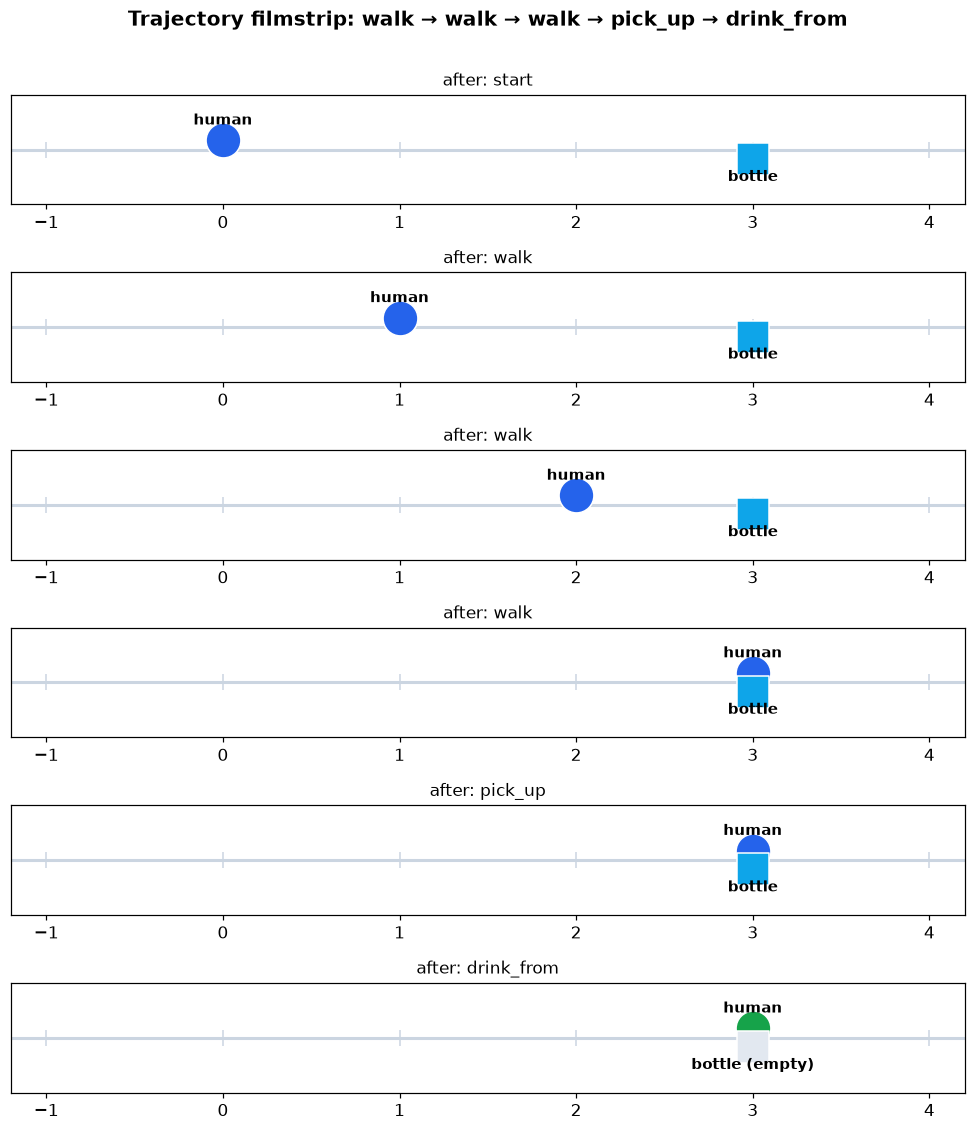

In [63]:
import copy

# Replay to capture a snapshot of the world after each executed action.
replay = build_world()
frames = [copy.deepcopy(replay)]
scores = [evaluate(objective, replay, [])]
history = []
for a in result.history:
    act = a.spec.bind(actor=a.actor, target=a.target)
    replay.apply(act)
    history.append(act)
    frames.append(copy.deepcopy(replay))
    scores.append(evaluate(objective, replay, history))

labels = ["start"] + [a.name for a in result.history]
n = len(frames)
fig, axes = plt.subplots(n, 1, figsize=(9, 1.7 * n))
for ax, frame, label in zip(axes, frames, labels):
    draw_world(frame, ax=ax, title=f"after: {label}")
fig.suptitle("Trajectory filmstrip: walk \u2192 walk \u2192 walk \u2192 pick_up \u2192 drink_from",
             fontsize=13, weight="bold", y=1.005)
plt.tight_layout(); plt.show()

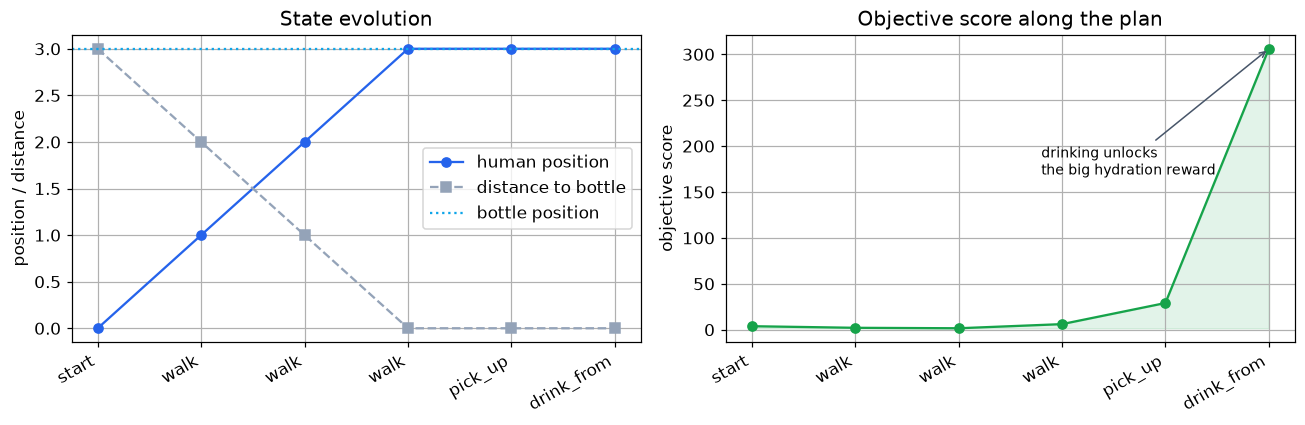

In [64]:
# How the world state and the objective score evolve along the executed plan.
positions = [f.entity(HUMAN).state["position"] for f in frames]
distances = [abs(f.entity(HUMAN).state["position"] - f.entity(BOTTLE).state["position"]) for f in frames]
steps = list(range(n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(steps, positions, "-o", color=ACCENT, label="human position")
ax1.plot(steps, distances, "--s", color=MUTED, label="distance to bottle")
ax1.axhline(3, color="#0ea5e9", ls=":", label="bottle position")
ax1.set_xticks(steps); ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_ylabel("position / distance"); ax1.set_title("State evolution"); ax1.legend()

ax2.plot(steps, scores, "-o", color=ACCENT2)
ax2.fill_between(steps, scores, min(scores), alpha=0.12, color=ACCENT2)
ax2.set_xticks(steps); ax2.set_xticklabels(labels, rotation=30, ha="right")
ax2.set_ylabel("objective score"); ax2.set_title("Objective score along the plan")
ax2.annotate("drinking unlocks\nthe big hydration reward",
             xy=(n - 1, scores[-1]), xytext=(n - 3.2, scores[-1] - (max(scores) - min(scores)) * 0.45),
             arrowprops=dict(arrowstyle="->", color="#475569"), fontsize=9)
plt.tight_layout(); plt.show()

## Step 6 — Why the horizon matters (a real MPC lesson)

MPC only sees `horizon` steps ahead. The goal here is **5 actions away**
(`walk×3 → pick_up → drink`). If the horizon is too short, the planner cannot *see*
the big hydration reward, and the objective's small effort penalty makes “do nothing”
look locally optimal — a classic short-horizon trap.

Let's sweep the horizon and measure how many actions the controller takes and whether
it reaches the goal. We reuse the *same* synthesized objective, so this isolates the
planner's look-ahead depth.

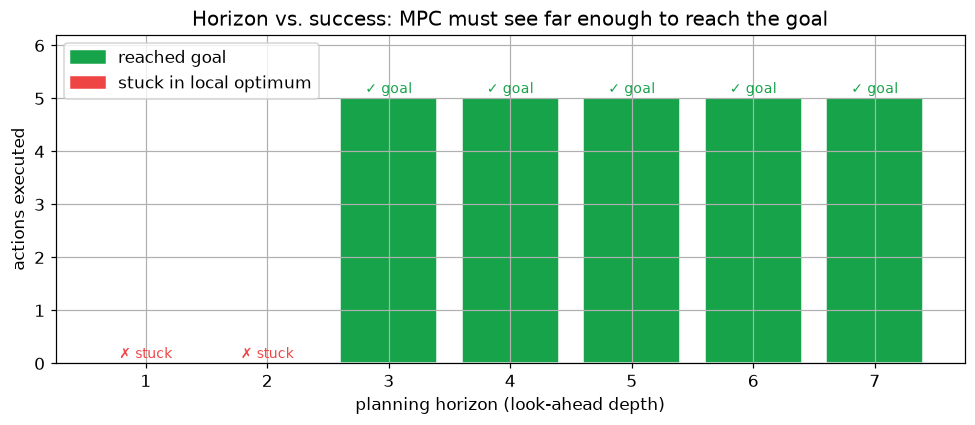

Smallest horizon that reaches the goal: 3


In [65]:
horizons = list(range(1, 8))
steps_taken, reached = [], []
for h in horizons:
    e = build_world()
    r = Controller(horizon=h, max_steps=20).run(e, objective=objective)
    steps_taken.append(len(r.history))
    reached.append(r.reached_goal)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT2 if ok else "#ef4444" for ok in reached]
bars = ax.bar(horizons, steps_taken, color=colors, edgecolor="white")
for h, s, ok in zip(horizons, steps_taken, reached):
    ax.text(h, s + 0.1, "\u2713 goal" if ok else "\u2717 stuck", ha="center",
            fontsize=9, color=ACCENT2 if ok else "#ef4444")
ax.set_xlabel("planning horizon (look-ahead depth)")
ax.set_ylabel("actions executed")
ax.set_title("Horizon vs. success: MPC must see far enough to reach the goal")
ax.set_ylim(0, max(steps_taken) + 1.2)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ACCENT2, label="reached goal"),
                   Patch(color="#ef4444", label="stuck in local optimum")])
plt.tight_layout(); plt.show()

first_ok = next((h for h, ok in zip(horizons, reached) if ok), None)
print(f"Smallest horizon that reaches the goal: {first_ok}")

The red bars are short-horizon runs that stall; the green bars see far enough to chase
the hydration reward. This is not a bug in the framework — it is the fundamental
trade-off of MPC, made visible. In a real system you would tune the horizon, or have
the LLM add *progress shaping* (e.g. a proximity reward) so even a short horizon points
the right way.

## Recap — what just happened

1. **We modeled a world** from three reusable framework primitives: `ActionSpec`,
   `Entity`, `Environment` — with preconditions encoding *affordance* (what *can*
   happen).
2. **We serialized it** into a JSON description plus an `attribute_map` that pins down
   exactly what the model may read.
3. **The LLM wrote the objective** — the *desirability* of states — as straight Python,
   never told the plan.
4. **The sandbox** ran that untrusted code safely over a read-only snapshot.
5. **The discrete MPC planner** searched a few steps ahead and the **controller**
   committed one action at a time until the human was hydrated.
6. **We saw the horizon trade-off** that governs every MPC system.

### Make it your own

To model a different task you only subclass the same primitives:

```python
class Drone(Entity):
    kind = "active_agent"
    def outgoing_actions(self):
        return [ASCEND, DESCEND, MOVE]
    def incoming_actions(self):
        return []

class DeliveryWorld(Environment):
    def is_terminal(self):
        return self.entity("parcel").state.get("delivered") is True
```

...write a one-line goal, and let the language model synthesize the objective. The
planner and controller stay exactly the same — that is the promise of LG-OMPC.